# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Fast Food Cheat Meal Dataset](https://www.kaggle.com/datasets/samartalwar/fast-food-calorie-shock-food-vs-workout-burn/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('fast_food_cheat_meal_workout_burn.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,order_id,fast_food_chain,meal_category,item_count,total_calories,fat_grams,saturated_fat_grams,carb_grams,sugar_grams,protein_grams,sodium_mg,consumer_gender,consumer_age,consumer_weight_kg,fitness_level,thermic_effect_calories,net_caloric_surplus,walking_burn_time_min,cycling_burn_time_min,running_burn_time_min,hiit_burn_time_min,daily_calorie_allowance_pct,workout_shock_tier
0,FFC-00001,McDonald's,Late-Night Value Menu Binge,3,1015,47,19,117,55,32,1632,Male,61,96.0,Moderately Active,77.9,937.1,168.3,80.8,60.2,46.5,50.7,High Sweat Penalty
1,FFC-00002,Taco Bell,Fried Chicken Bucket & Slaw,5,1849,103,32,166,61,65,2806,Female,65,53.6,Moderately Active,136.7,1712.3,550.7,261.7,185.5,161.1,92.4,Extreme / Half-Marathon Toll
2,FFC-00003,Domino's Pizza,Pizza Feast & Cheesy Bread,2,1920,106,50,184,61,57,2122,Female,35,67.0,Moderately Active,135.0,1785.0,463.9,219.5,157.8,131.1,96.0,Extreme / Half-Marathon Toll
3,FFC-00004,McDonald's,Dessert Overload & Large Shake,2,1255,67,25,135,42,27,1883,Female,61,62.6,Sedentary,82.3,1172.7,351.0,166.5,120.3,103.4,62.7,Extreme / Half-Marathon Toll
4,FFC-00005,Taco Bell,Double Burger & Large Fry,4,1665,88,32,155,69,62,2305,Male,19,73.0,Moderately Active,127.4,1537.6,361.3,170.9,119.1,104.9,83.2,Severe Cardio Deficit


## last Five row

In [4]:
df.tail()

,order_id,fast_food_chain,meal_category,item_count,total_calories,fat_grams,saturated_fat_grams,carb_grams,sugar_grams,protein_grams,sodium_mg,consumer_gender,consumer_age,consumer_weight_kg,fitness_level,thermic_effect_calories,net_caloric_surplus,walking_burn_time_min,cycling_burn_time_min,running_burn_time_min,hiit_burn_time_min,daily_calorie_allowance_pct,workout_shock_tier
7995,FFC-07996,Burger King,Fried Chicken Bucket & Slaw,2,1762,84,29,170,77,82,3039,Male,20,72.1,Highly Trained,151.5,1610.5,357.1,168.5,117.1,100.9,88.1,Severe Cardio Deficit
7996,FFC-07997,Subway,Fried Chicken Bucket & Slaw,3,2818,152,57,326,88,37,4337,Male,25,105.4,Sedentary,168.7,2649.3,473.2,225.5,158.5,132.1,140.9,Extreme / Half-Marathon Toll
7997,FFC-07998,Wendy's,Pizza Feast & Cheesy Bread,5,1240,63,27,126,48,43,1758,Male,56,114.9,Sedentary,94.7,1145.3,192.8,81.4,67.1,52.6,62.0,High Sweat Penalty
7998,FFC-07999,KFC,Fried Chicken Bucket & Slaw,4,1825,78,27,179,87,102,2940,Female,48,52.3,Moderately Active,173.3,1651.7,546.7,259.1,180.2,152.4,91.2,Extreme / Half-Marathon Toll
7999,FFC-08000,Burger King,Pizza Feast & Cheesy Bread,3,2891,163,65,346,95,15,4423,Male,64,73.7,Highly Trained,155.1,2735.9,595.1,286.4,204.6,174.9,144.6,Extreme / Half-Marathon Toll


## Shape of our dataset

In [5]:
df.shape

(8000, 23)

## List out all columns

In [6]:
df.columns

Index(['order_id', 'fast_food_chain', 'meal_category', 'item_count',
       'total_calories', 'fat_grams', 'saturated_fat_grams', 'carb_grams',
       'sugar_grams', 'protein_grams', 'sodium_mg', 'consumer_gender',
       'consumer_age', 'consumer_weight_kg', 'fitness_level',
       'thermic_effect_calories', 'net_caloric_surplus',
       'walking_burn_time_min', 'cycling_burn_time_min',
       'running_burn_time_min', 'hiit_burn_time_min',
       'daily_calorie_allowance_pct', 'workout_shock_tier'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

order_id                        object
fast_food_chain                 object
meal_category                   object
item_count                       int64
total_calories                   int64
fat_grams                        int64
saturated_fat_grams              int64
carb_grams                       int64
sugar_grams                      int64
protein_grams                    int64
sodium_mg                        int64
consumer_gender                 object
consumer_age                     int64
consumer_weight_kg             float64
fitness_level                   object
thermic_effect_calories        float64
net_caloric_surplus            float64
walking_burn_time_min          float64
cycling_burn_time_min          float64
running_burn_time_min          float64
hiit_burn_time_min             float64
daily_calorie_allowance_pct    float64
workout_shock_tier              object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     8000 non-null   object 
 1   fast_food_chain              8000 non-null   object 
 2   meal_category                8000 non-null   object 
 3   item_count                   8000 non-null   int64  
 4   total_calories               8000 non-null   int64  
 5   fat_grams                    8000 non-null   int64  
 6   saturated_fat_grams          8000 non-null   int64  
 7   carb_grams                   8000 non-null   int64  
 8   sugar_grams                  8000 non-null   int64  
 9   protein_grams                8000 non-null   int64  
 10  sodium_mg                    8000 non-null   int64  
 11  consumer_gender              8000 non-null   object 
 12  consumer_age                 8000 non-null   int64  
 13  consumer_weight_kg

## Check Null Value

In [9]:
df.isnull().sum()

order_id                       0
fast_food_chain                0
meal_category                  0
item_count                     0
total_calories                 0
fat_grams                      0
saturated_fat_grams            0
carb_grams                     0
sugar_grams                    0
protein_grams                  0
sodium_mg                      0
consumer_gender                0
consumer_age                   0
consumer_weight_kg             0
fitness_level                  0
thermic_effect_calories        0
net_caloric_surplus            0
walking_burn_time_min          0
cycling_burn_time_min          0
running_burn_time_min          0
hiit_burn_time_min             0
daily_calorie_allowance_pct    0
workout_shock_tier             0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,item_count,total_calories,fat_grams,saturated_fat_grams,carb_grams,sugar_grams,protein_grams,sodium_mg,consumer_age,consumer_weight_kg,thermic_effect_calories,net_caloric_surplus,walking_burn_time_min,cycling_burn_time_min,running_burn_time_min,hiit_burn_time_min,daily_calorie_allowance_pct
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3.502125,1602.574375,80.061375,31.985125,165.961375,62.250750,54.037250,2399.537000,41.482375,77.804587,121.555850,1481.018525,350.152287,165.043288,117.917537,100.487000,80.128575
std,1.118996,672.128080,34.288636,14.401470,70.790342,31.795058,30.690342,1072.813548,13.932712,13.929379,52.717465,622.806400,164.466555,77.544694,55.491633,47.268065,33.606582
min,2.000000,750.000000,32.000000,10.000000,66.000000,14.000000,15.000000,826.000000,18.000000,48.000000,47.100000,675.500000,100.500000,42.000000,26.300000,22.900000,37.500000
25%,2.000000,1080.000000,53.000000,21.000000,110.000000,39.000000,30.000000,1564.000000,29.000000,68.000000,79.200000,997.350000,224.875000,106.200000,76.100000,64.700000,54.000000
50%,4.000000,1479.000000,74.000000,29.000000,153.000000,55.000000,48.000000,2192.000000,42.000000,77.600000,112.200000,1366.950000,319.150000,149.950000,107.400000,91.450000,74.000000
75%,5.000000,2008.000000,100.000000,40.000000,208.000000,79.000000,71.000000,3009.250000,54.000000,87.200000,152.725000,1854.300000,439.700000,207.425000,147.500000,126.200000,100.400000
max,5.000000,3600.000000,190.000000,75.000000,380.000000,175.000000,140.000000,5800.000000,65.000000,129.400000,291.100000,3429.200000,1299.200000,614.600000,436.500000,369.500000,180.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

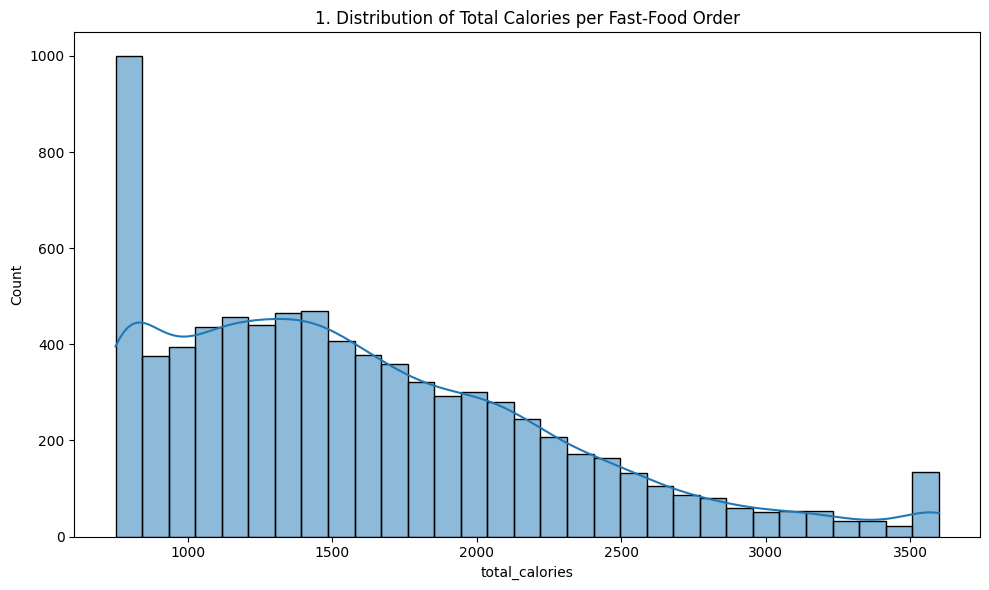

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total_calories', kde=True)
plt.title(f'{plot_no}. Distribution of Total Calories per Fast-Food Order')
show_fig()
plot_no += 1

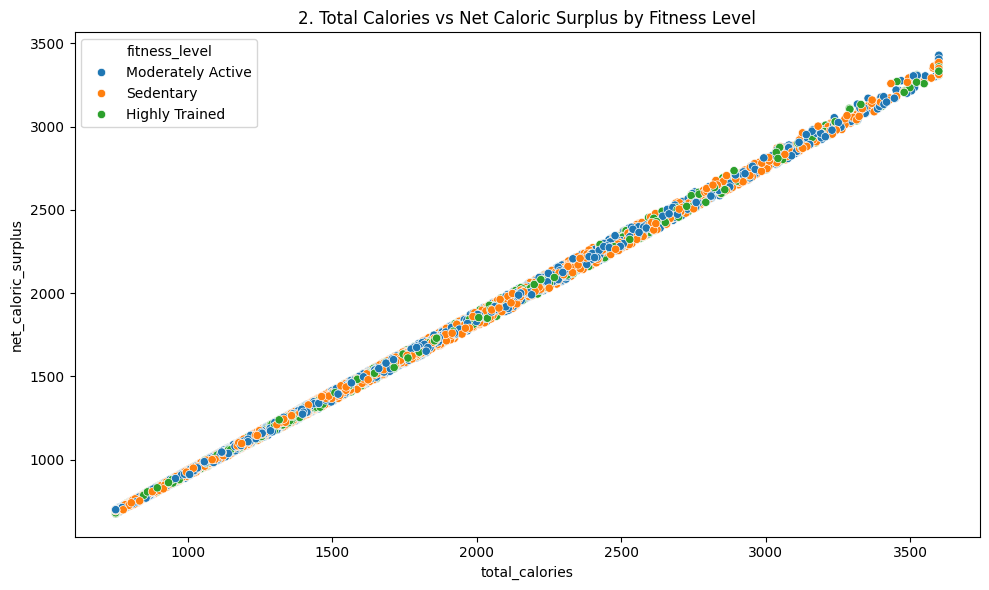

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_calories', y='net_caloric_surplus', hue='fitness_level')
plt.title(f'{plot_no}. Total Calories vs Net Caloric Surplus by Fitness Level')
show_fig()
plot_no += 1

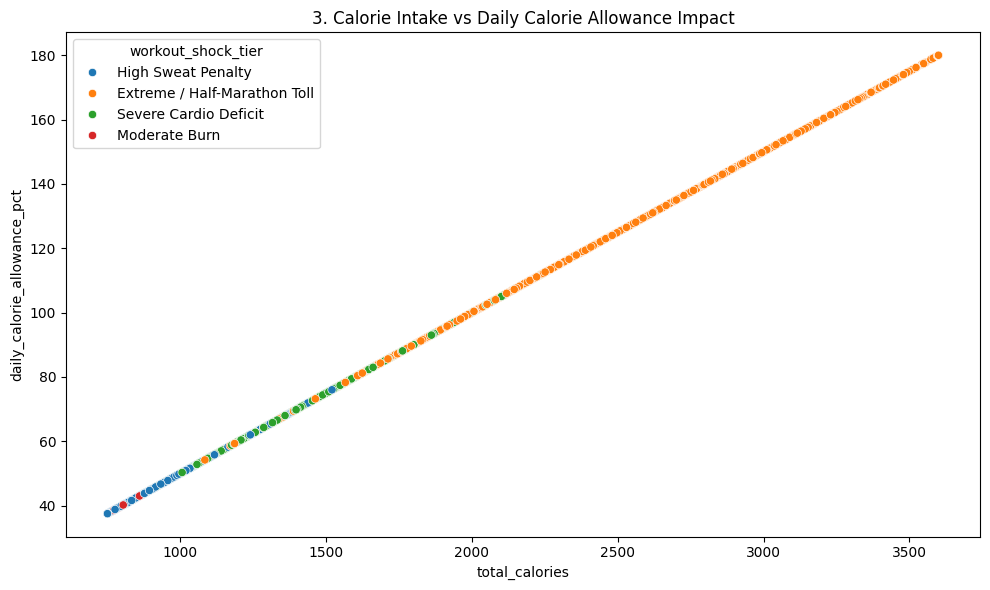

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_calories', y='daily_calorie_allowance_pct', hue='workout_shock_tier')
plt.title(f'{plot_no}. Calorie Intake vs Daily Calorie Allowance Impact')
show_fig()
plot_no += 1

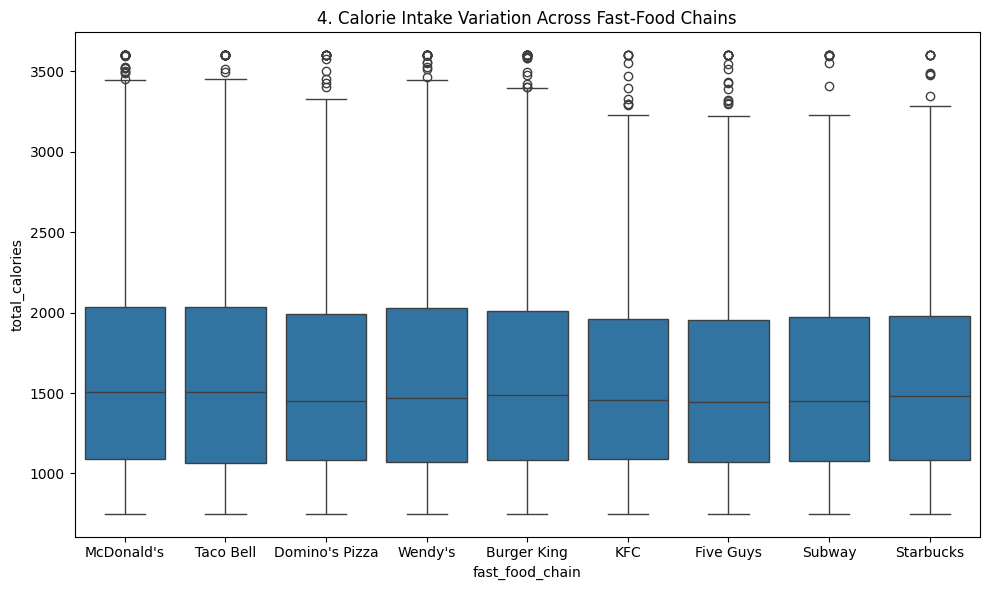

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fast_food_chain', y='total_calories')
plt.title(f'{plot_no}. Calorie Intake Variation Across Fast-Food Chains')
show_fig()
plot_no += 1

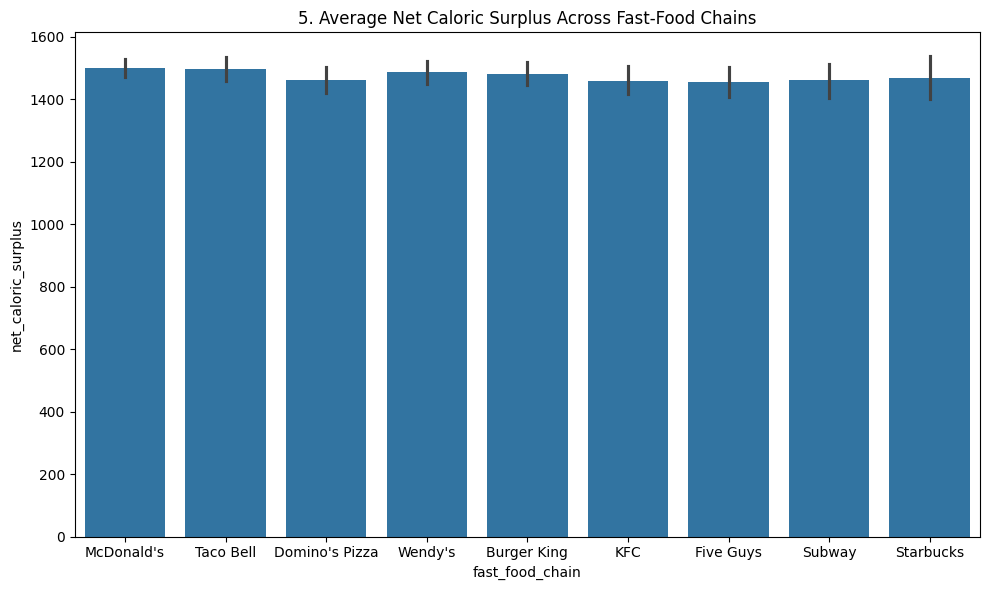

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='fast_food_chain', y='net_caloric_surplus', estimator='mean')
plt.title(f'{plot_no}. Average Net Caloric Surplus Across Fast-Food Chains')
show_fig()
plot_no += 1

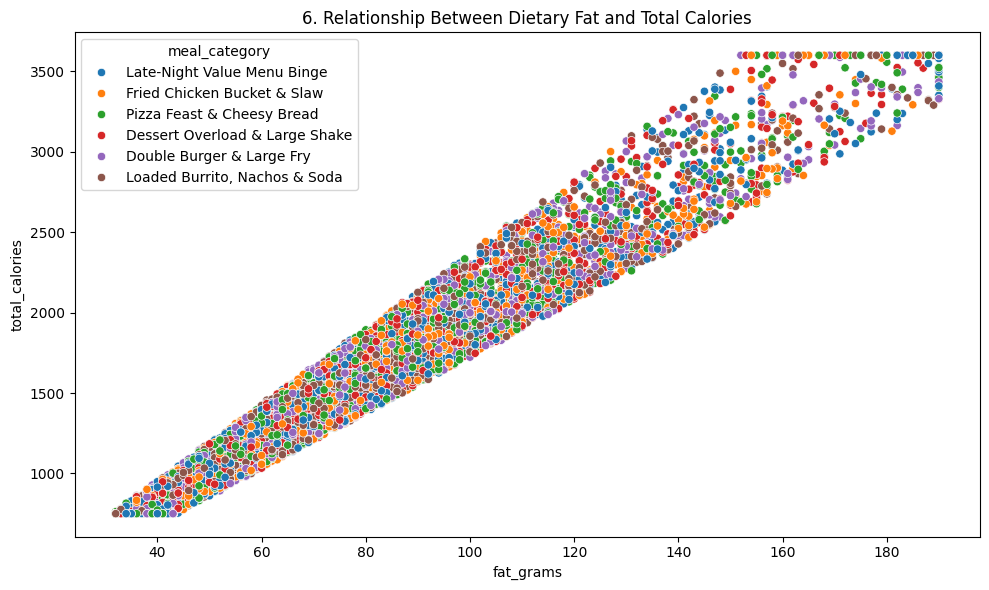

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fat_grams', y='total_calories', hue='meal_category')
plt.title(f'{plot_no}. Relationship Between Dietary Fat and Total Calories')
show_fig()
plot_no += 1

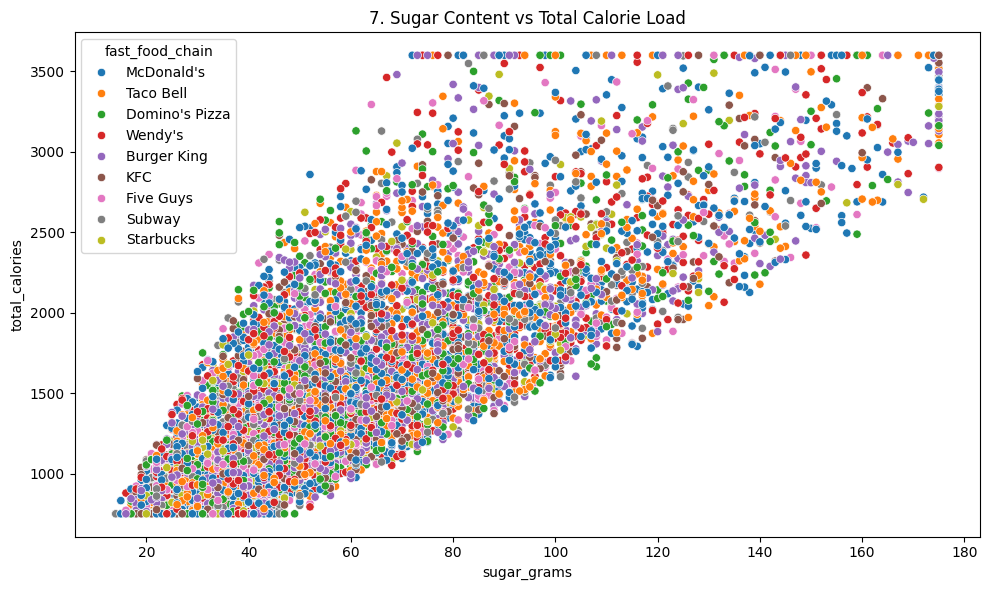

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sugar_grams', y='total_calories', hue='fast_food_chain')
plt.title(f'{plot_no}. Sugar Content vs Total Calorie Load')
show_fig()
plot_no += 1

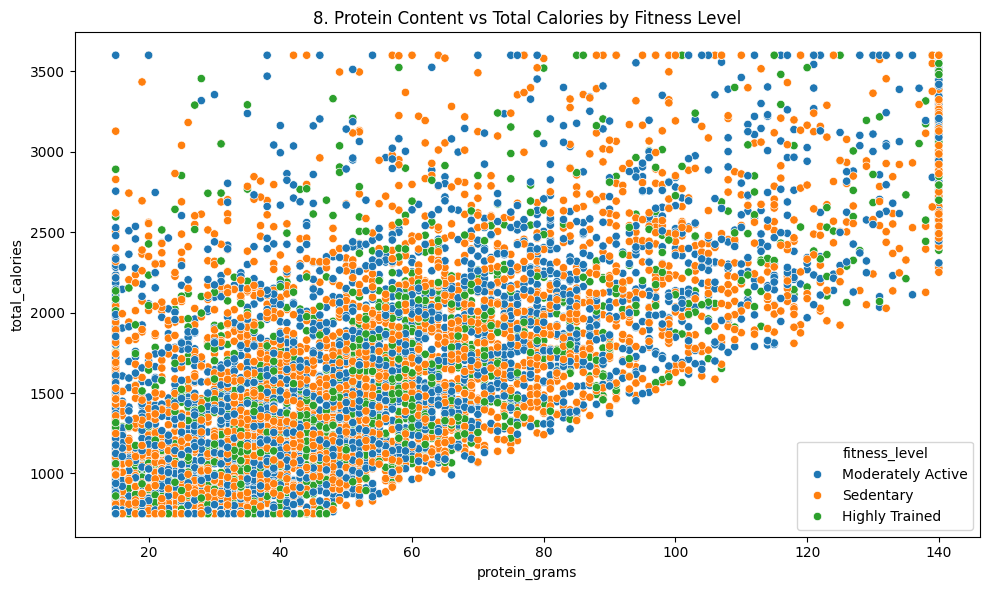

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='protein_grams', y='total_calories', hue='fitness_level')
plt.title(f'{plot_no}. Protein Content vs Total Calories by Fitness Level')
show_fig()
plot_no += 1

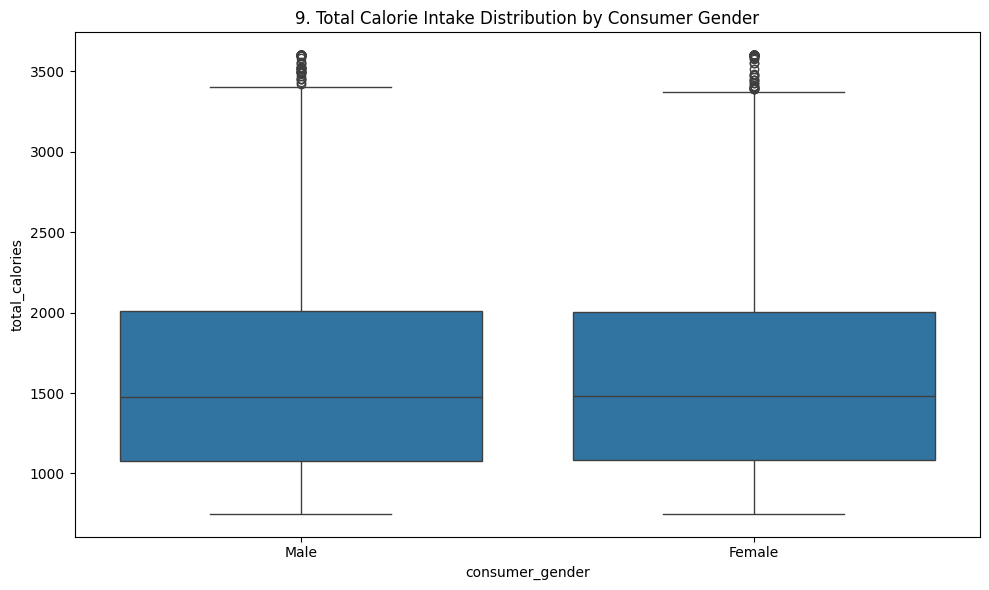

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='consumer_gender', y='total_calories')
plt.title(f'{plot_no}. Total Calorie Intake Distribution by Consumer Gender')
show_fig()
plot_no += 1

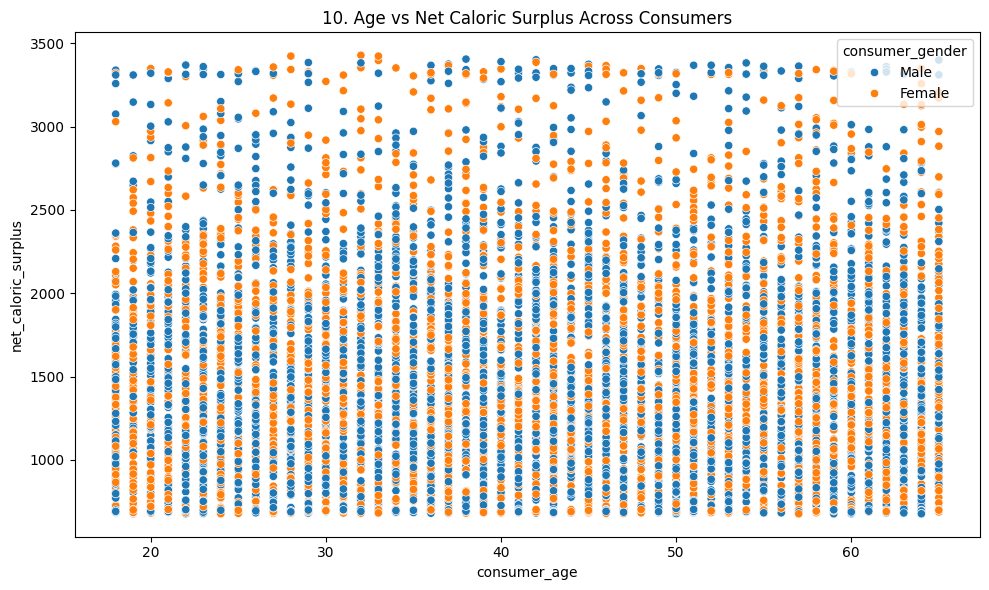

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='consumer_age', y='net_caloric_surplus', hue='consumer_gender')
plt.title(f'{plot_no}. Age vs Net Caloric Surplus Across Consumers')
show_fig()
plot_no += 1

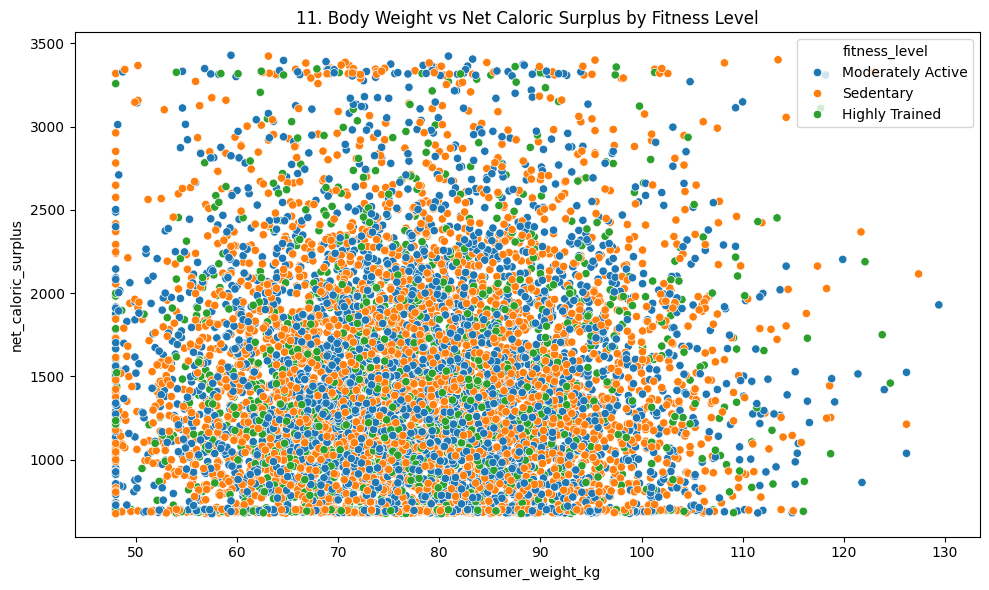

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='consumer_weight_kg', y='net_caloric_surplus', hue='fitness_level')
plt.title(f'{plot_no}. Body Weight vs Net Caloric Surplus by Fitness Level')
show_fig()
plot_no += 1

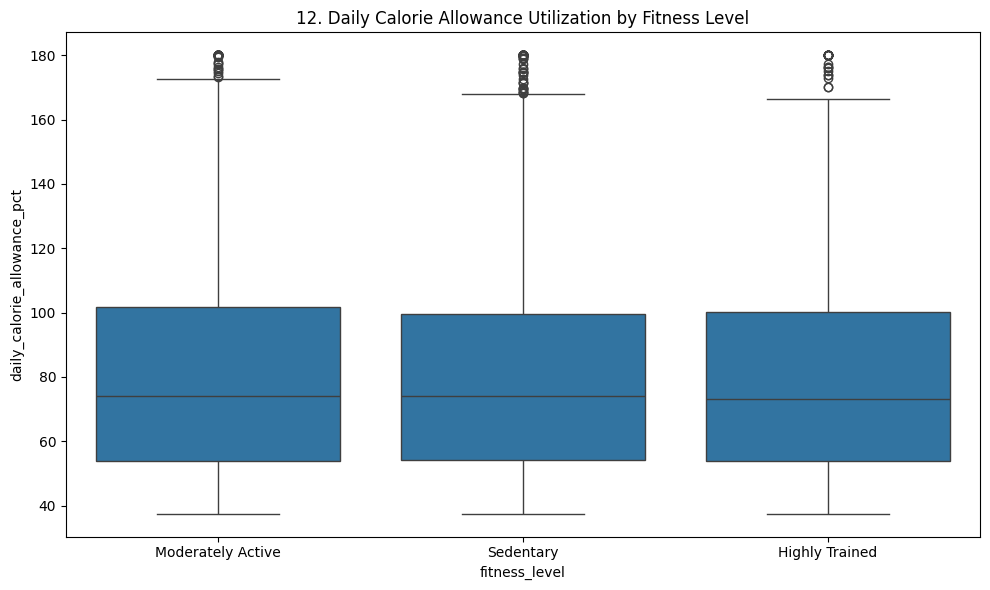

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='fitness_level', y='daily_calorie_allowance_pct')
plt.title(f'{plot_no}. Daily Calorie Allowance Utilization by Fitness Level')
show_fig()
plot_no += 1

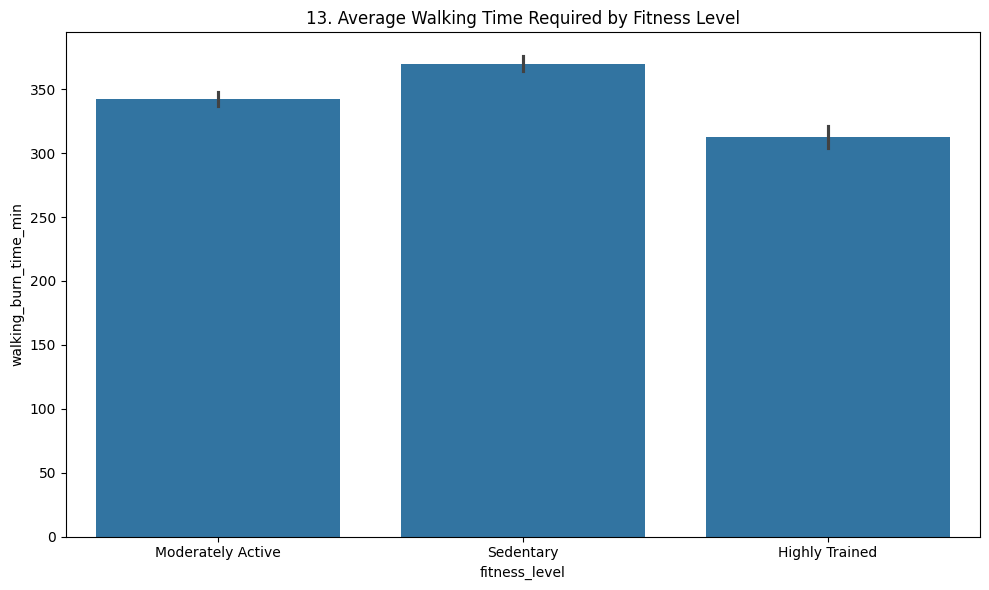

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='fitness_level', y='walking_burn_time_min', estimator='mean')
plt.title(f'{plot_no}. Average Walking Time Required by Fitness Level')
show_fig()
plot_no += 1

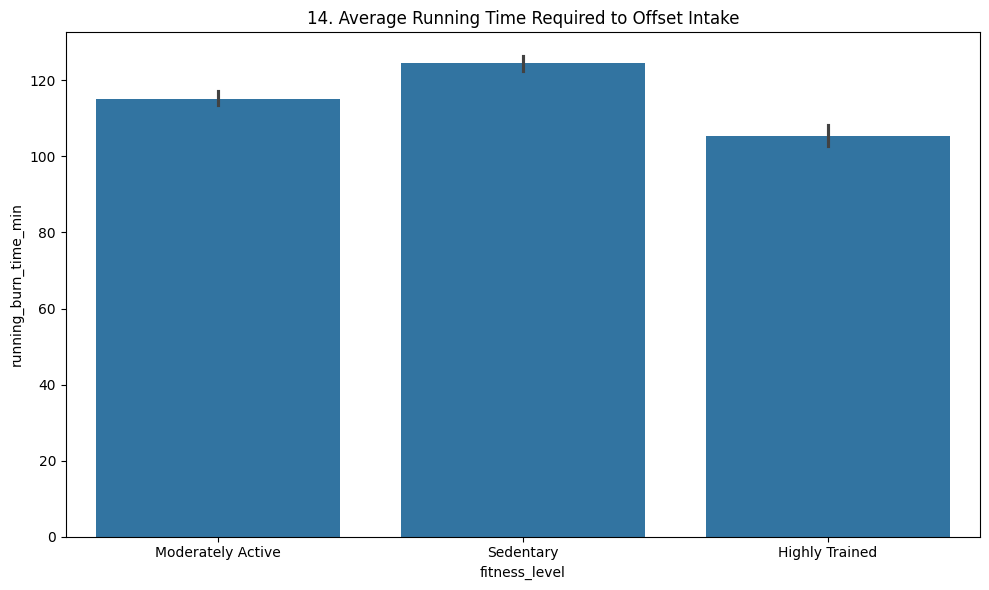

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='fitness_level', y='running_burn_time_min', estimator='mean')
plt.title(f'{plot_no}. Average Running Time Required to Offset Intake')
show_fig()
plot_no += 1

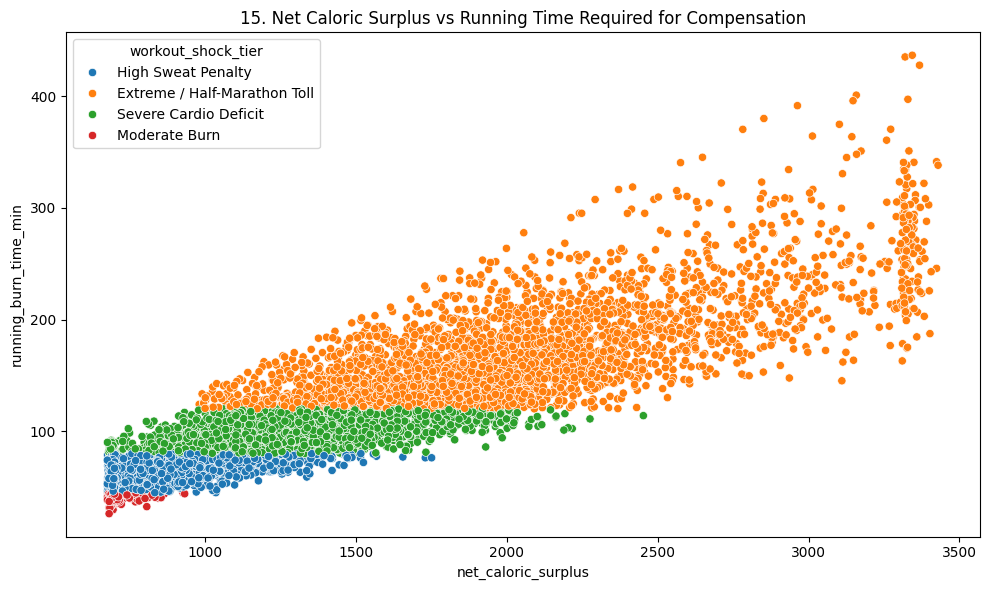

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='net_caloric_surplus', y='running_burn_time_min', hue='workout_shock_tier')
plt.title(f'{plot_no}. Net Caloric Surplus vs Running Time Required for Compensation')
show_fig()
plot_no += 1

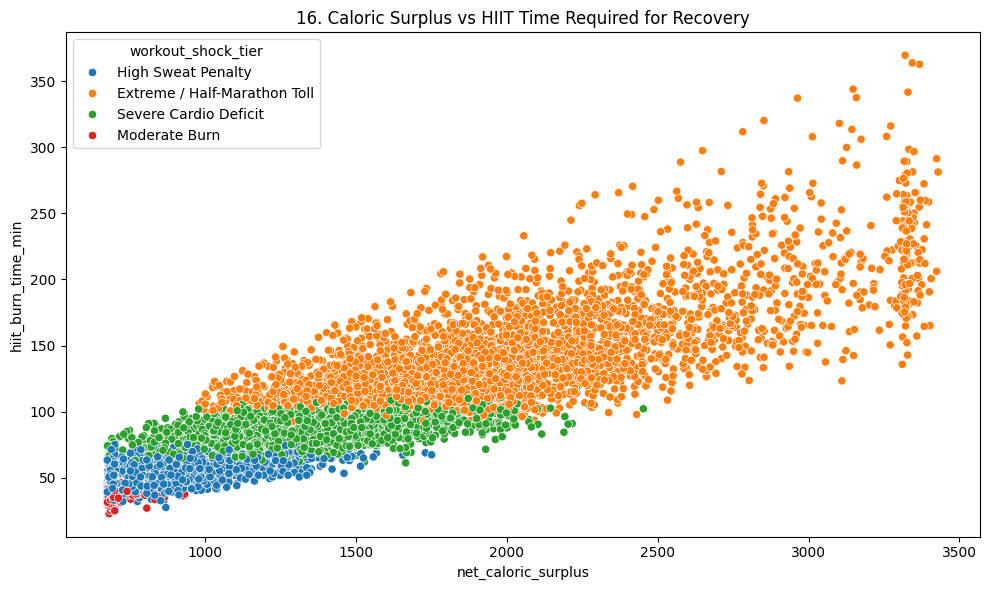

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='net_caloric_surplus', y='hiit_burn_time_min', hue='workout_shock_tier')
plt.title(f'{plot_no}. Caloric Surplus vs HIIT Time Required for Recovery')
show_fig()
plot_no += 1

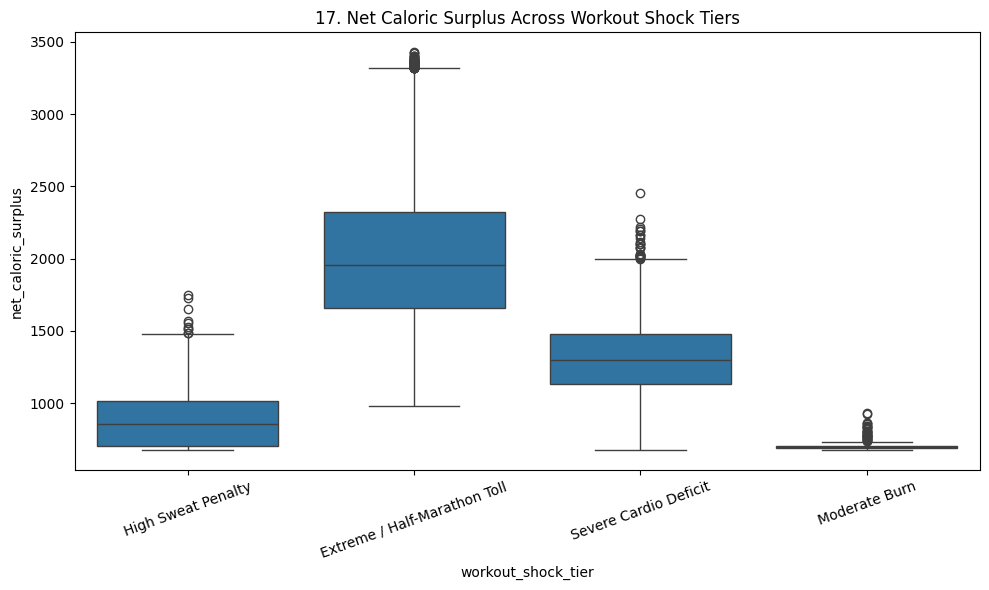

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='workout_shock_tier', y='net_caloric_surplus')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Net Caloric Surplus Across Workout Shock Tiers')
show_fig()
plot_no += 1

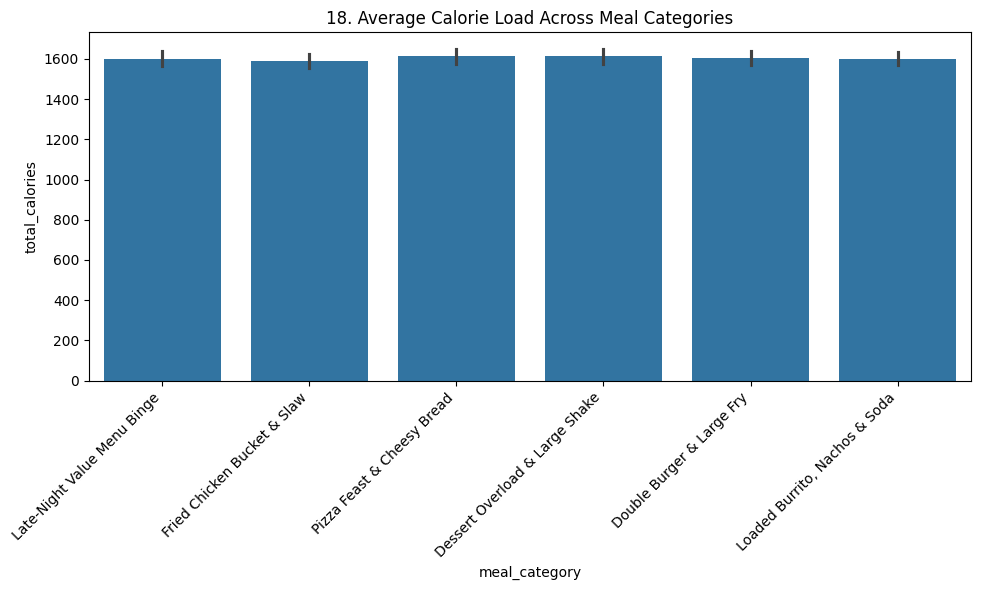

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='meal_category', y='total_calories', estimator='mean')
plt.xticks(rotation=45, ha='right')
plt.title(f'{plot_no}. Average Calorie Load Across Meal Categories')
show_fig()
plot_no += 1

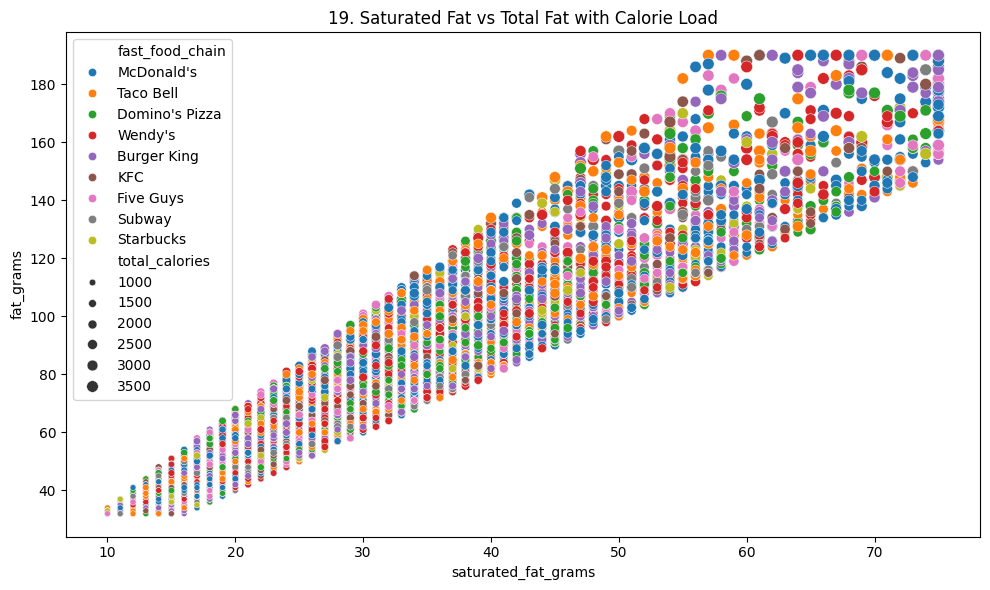

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='saturated_fat_grams', y='fat_grams', size='total_calories', hue='fast_food_chain')
plt.title(f'{plot_no}. Saturated Fat vs Total Fat with Calorie Load')
show_fig()
plot_no += 1

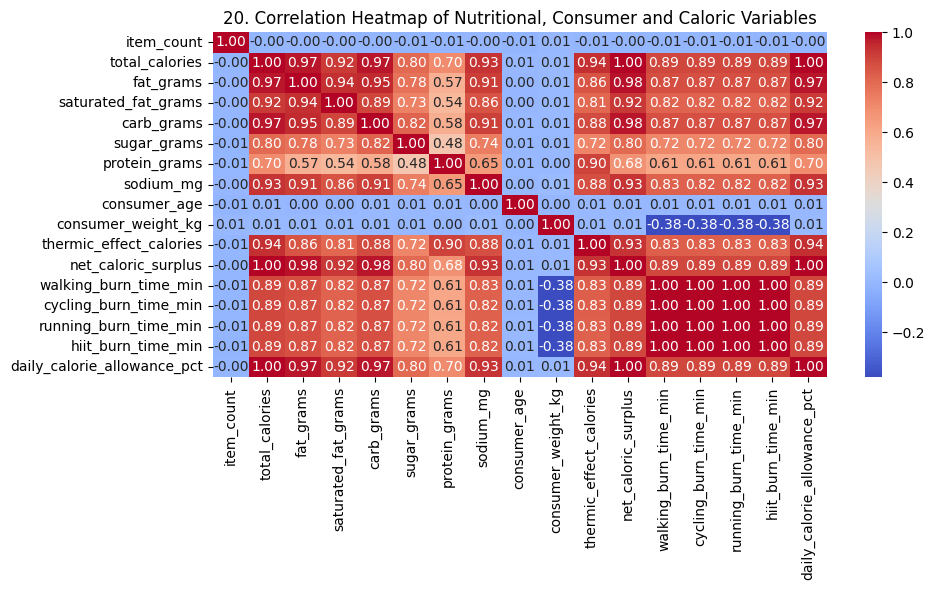

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Nutritional, Consumer and Caloric Variables')
show_fig()
plot_no += 1

# Model Training

## Using Machine Learning

### Select features and target

In [33]:
X = df[['fat_grams', 'saturated_fat_grams', 'carb_grams', 'sugar_grams',
        'protein_grams', 'sodium_mg', 'consumer_age', 'consumer_weight_kg']]
y = df['net_caloric_surplus']

### Split the dataset

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scale numerical features

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train the regression model

In [36]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Predict test data

In [37]:
y_pred = model.predict(X_test)

### Evaluate model performance

In [38]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

R² Score: 0.9986
RMSE: 22.6261


### Plot actual vs predicted values

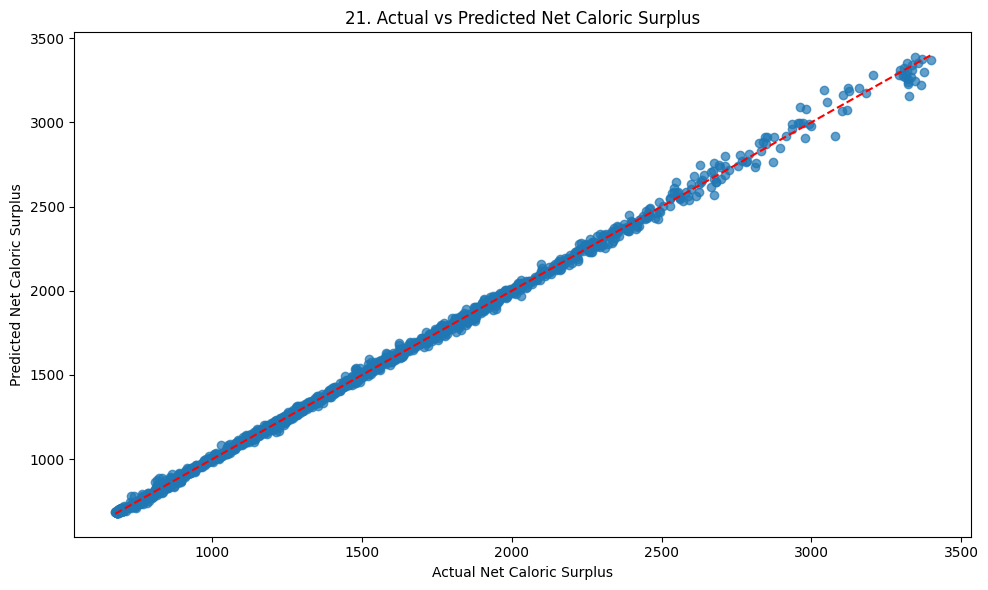

In [39]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Net Caloric Surplus')
plt.ylabel('Predicted Net Caloric Surplus')
plt.title(f'{plot_no}. Actual vs Predicted Net Caloric Surplus')
show_fig()

## Using Deep Learning

### Select relevant features and regression target

In [40]:
features = [
    'fat_grams', 'saturated_fat_grams', 'carb_grams', 'sugar_grams',
    'protein_grams', 'sodium_mg', 'consumer_age', 'consumer_weight_kg'
]
target = 'net_caloric_surplus'
data = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()
X = data[features].astype('float32')
y = data[target].astype('float32')

### Split training and testing data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scale features using training data only

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

### Build a deep neural network for regression

In [43]:
tf.keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.15),
    Dense(64, activation='relu'),
    Dropout(0.10),
    Dense(32, activation='relu'),
    Dense(1)
])

### Configure training and prevent unnecessary overfitting

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6
)

### Train the neural network

In [45]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1702165.3750 - mae: 1133.3165 - val_loss: 323048.0938 - val_mae: 495.5741 - learning_rate: 0.0010
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 187129.1719 - mae: 364.7566 - val_loss: 70177.8750 - val_mae: 223.2898 - learning_rate: 0.0010
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 55235.3555 - mae: 190.6678 - val_loss: 26434.3164 - val_mae: 133.3160 - learning_rate: 0.0010
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 31122.4570 - mae: 141.1657 - val_loss: 13951.7236 - val_mae: 96.2727 - learning_rate: 0.0010
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21839.8086 - mae: 116.9349 - val_loss: 7337.5654 - val_mae: 68.5959 - learning_rate: 0.0010
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 16332.0254 - mae: 100.1998 - val_loss: 4438.8008 - val_mae: 53.3197 - learning_rate: 0.0010
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 14527.403

### Evaluate predictions on unseen test data

In [46]:
y_pred = model.predict(X_test, verbose=0).ravel()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

R² Score: 0.9991
MAE: 8.6628
RMSE: 18.0617


### Plot actual vs predicted values

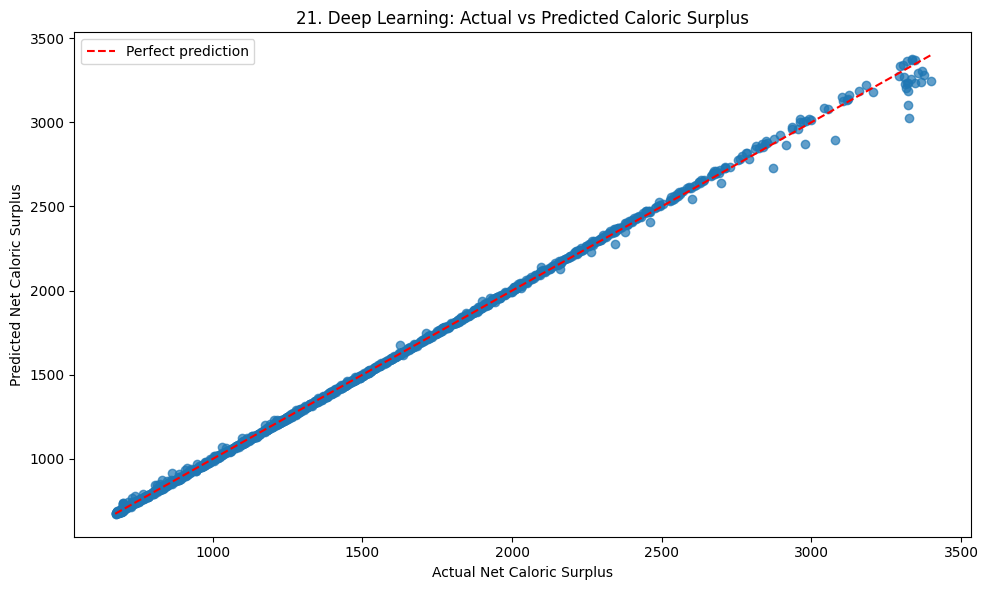

In [47]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [
    min(float(y_test.min()), float(y_pred.min())),
    max(float(y_test.max()), float(y_pred.max()))
]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Net Caloric Surplus')
plt.ylabel('Predicted Net Caloric Surplus')
plt.title(f'{plot_no}. Deep Learning: Actual vs Predicted Caloric Surplus')
plt.legend()
show_fig()
plot_no += 1

### Plot training and validation loss

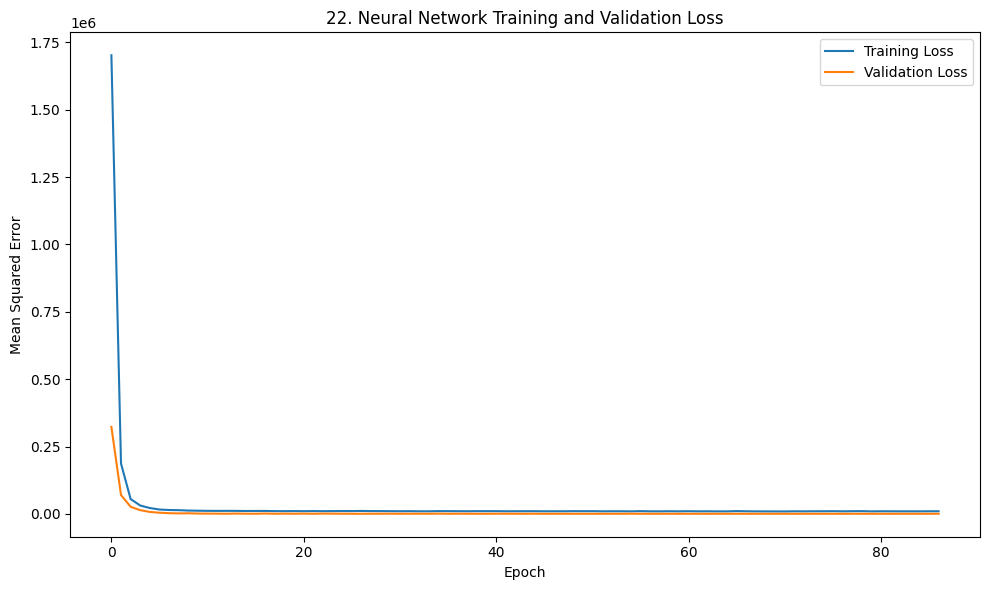

In [48]:
fig = plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title(f'{plot_no}. Neural Network Training and Validation Loss')
plt.legend()
show_fig()
plot_no += 1